           age        income  credit_score    loan_amount  employment_length  \
0    39.967142  73106.877027    616.241086   27913.814171           4.409519   
1    33.617357  57659.877200    642.774066   42439.974662           6.906390   
2    41.476885  37414.558971    610.379004   50744.462956           7.054051   
3    50.230299  26279.162694    634.601924  127398.476409           8.417891   
4    32.658466  51488.391671    555.319267   74803.596908           2.899425   
..         ...           ...           ...            ...                ...   
995  32.188997  62011.499284    653.874026   60559.584824           6.853105   
996  52.976865  35837.115114    662.887627   26078.728788           9.134232   
997  41.408429  23366.593997    587.911971   52674.190893          16.338731   
998  29.288210  33472.065960    666.708821  115537.595983           9.424109   
999  40.725828  25022.949871    642.237048   69165.617180           4.455803   

     default  tree_segment  cluster_seg

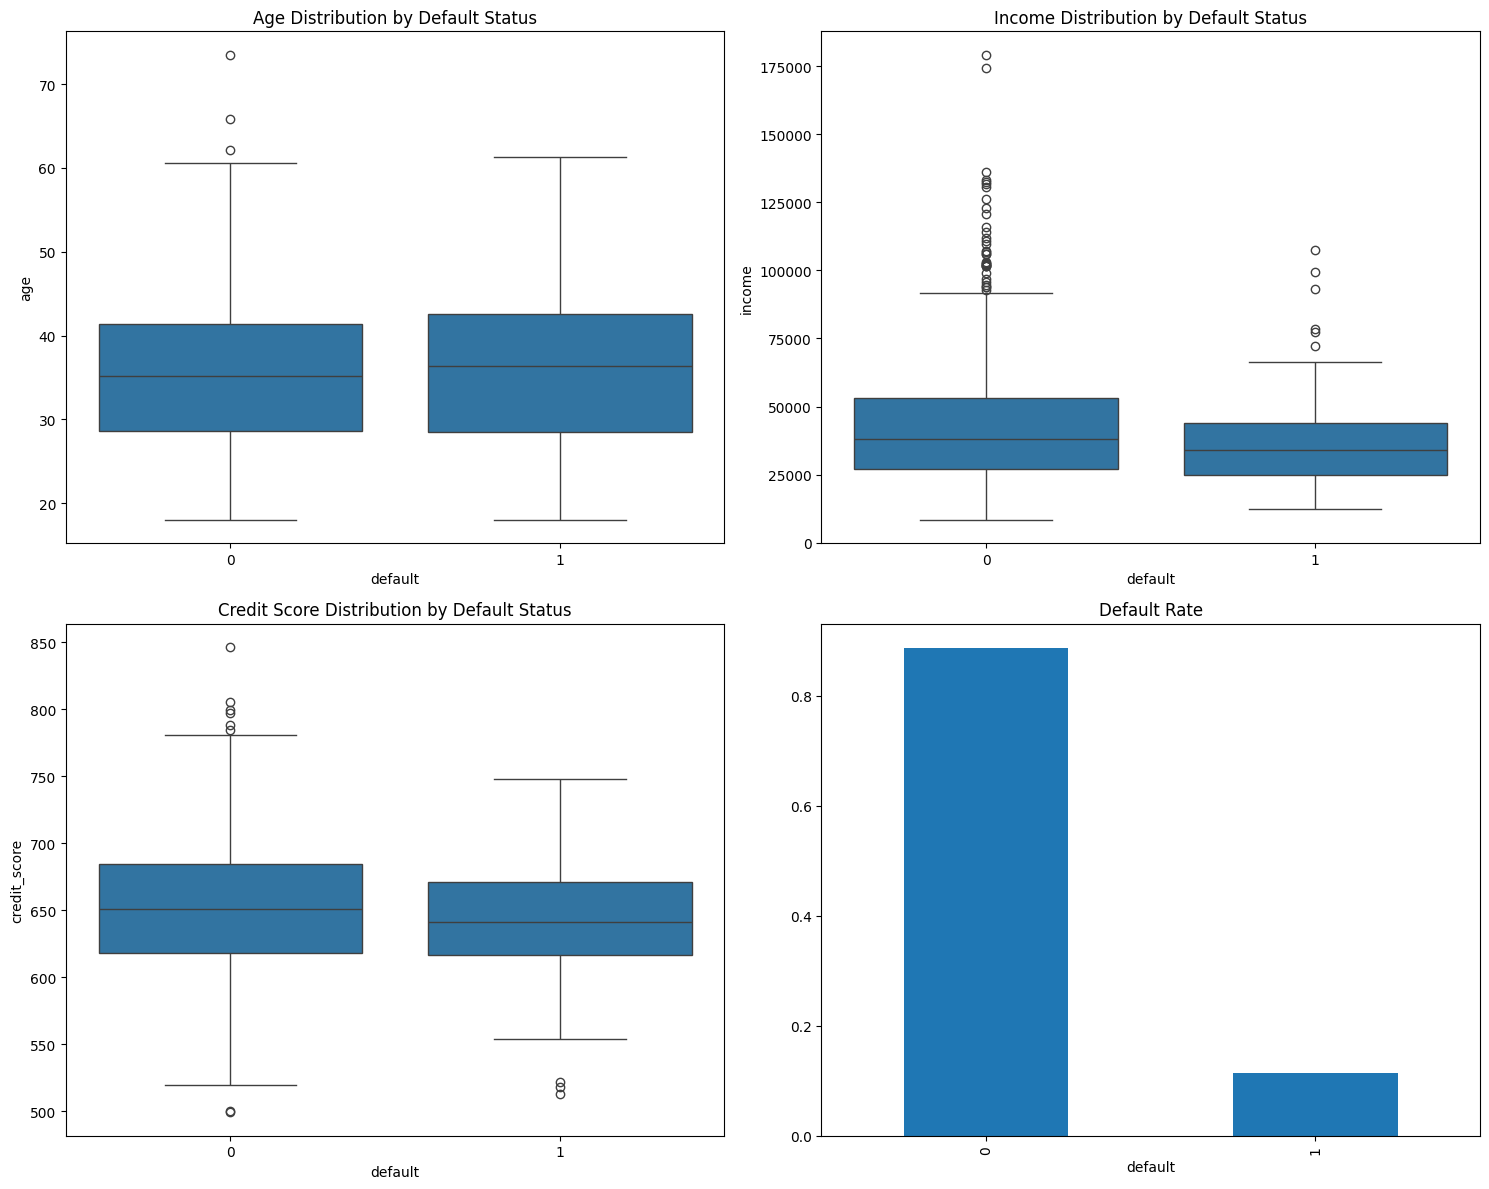

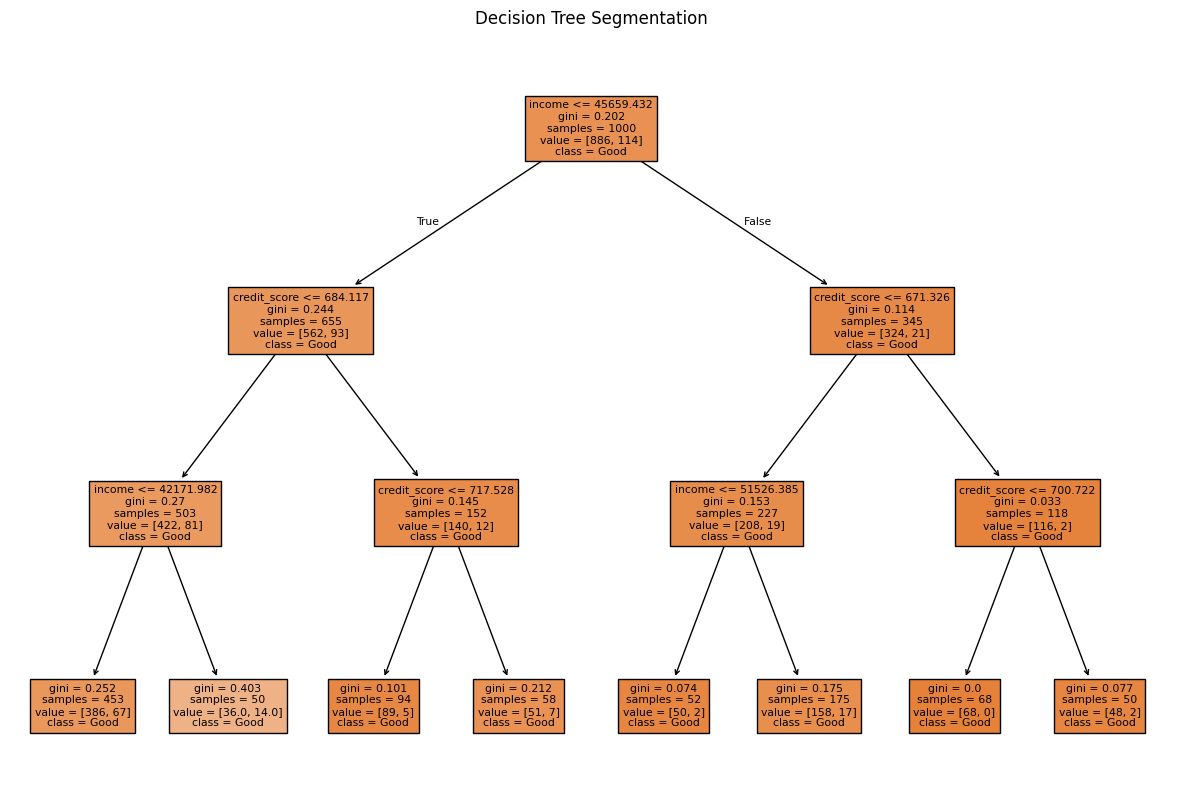

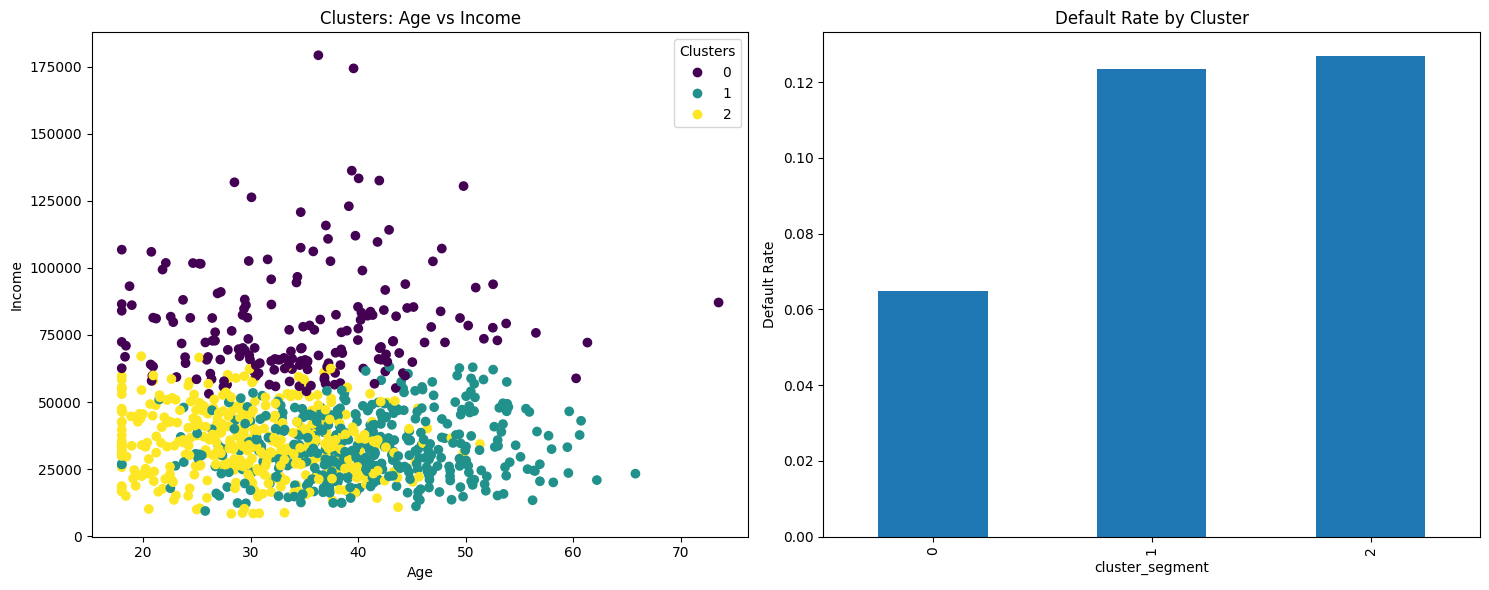

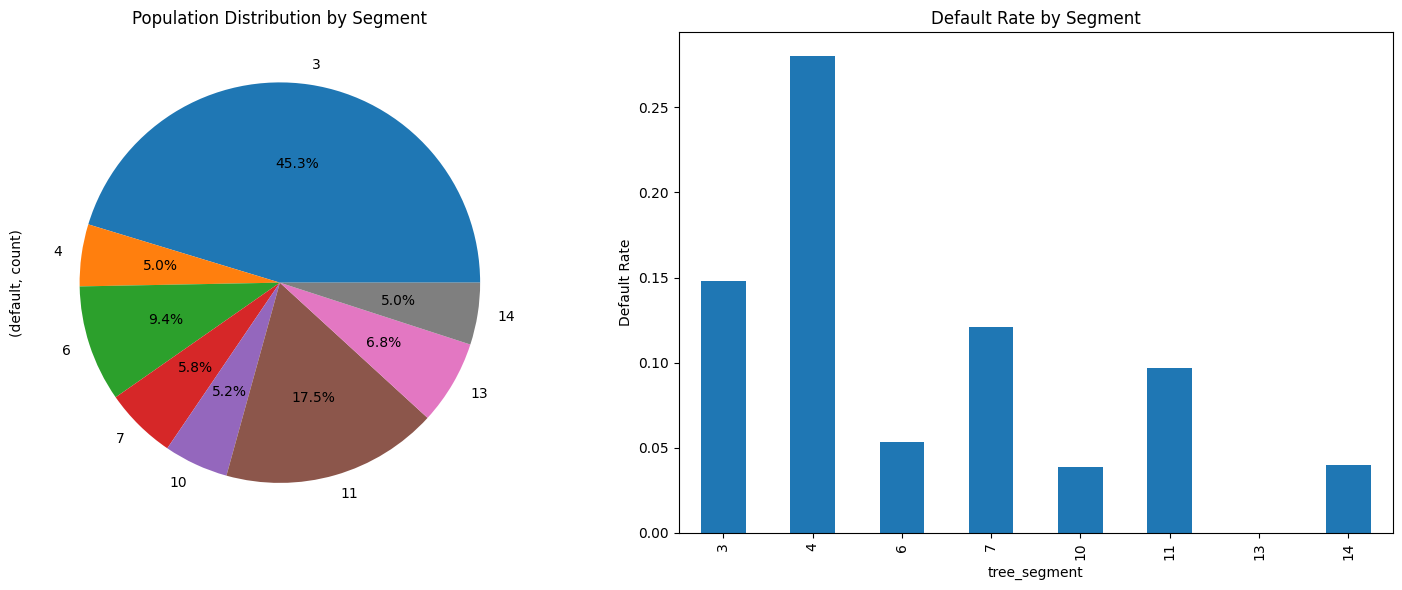

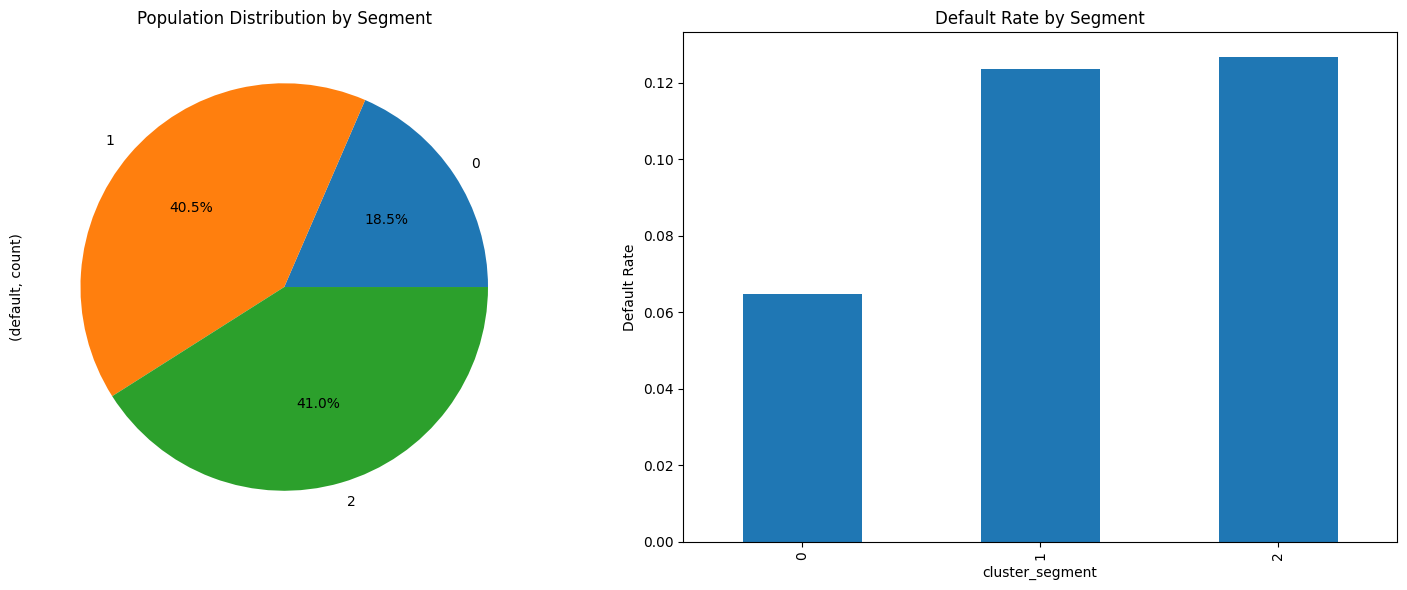

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Generate sample data
np.random.seed(42)

def generate_sample_data(n_samples=1000):
    """Generate sample credit data"""
    data = {
        'age': np.random.normal(35, 10, n_samples),
        'income': np.random.lognormal(10.5, 0.5, n_samples),
        'credit_score': np.random.normal(650, 50, n_samples),
        'loan_amount': np.random.lognormal(11, 0.4, n_samples),
        'employment_length': np.random.normal(7, 3, n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # Add some realistic constraints
    df['age'] = np.clip(df['age'], 18, 75)
    df['credit_score'] = np.clip(df['credit_score'], 300, 850)
    df['employment_length'] = np.clip(df['employment_length'], 0, 40)
    
    # Generate target variable with some patterns
    prob_default = 1 / (1 + np.exp(-(
        -2 
        + 0.03 * (df['age'] - 40) 
        - 0.5 * (df['credit_score'] - 650)/100
        + 0.2 * (np.log(df['loan_amount']) - 11)
    )))
    df['default'] = np.random.binomial(1, prob_default)
    
    return df

# Generate data
df = generate_sample_data(1000)

# 2. Exploratory Analysis
def plot_exploratory_analysis(df):
    """Plot initial data exploration"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Age vs Default
    sns.boxplot(x='default', y='age', data=df, ax=axes[0,0])
    axes[0,0].set_title('Age Distribution by Default Status')
    
    # Income vs Default
    sns.boxplot(x='default', y='income', data=df, ax=axes[0,1])
    axes[0,1].set_title('Income Distribution by Default Status')
    
    # Credit Score vs Default
    sns.boxplot(x='default', y='credit_score', data=df, ax=axes[1,0])
    axes[1,0].set_title('Credit Score Distribution by Default Status')
    
    # Default Rate
    df['default'].value_counts(normalize=True).plot(
        kind='bar', ax=axes[1,1], title='Default Rate'
    )
    
    plt.tight_layout()
    return fig

# 3. Tree-based Segmentation
def tree_segmentation_analysis(df):
    """Perform and visualize tree-based segmentation"""
    features = ['age', 'income', 'credit_score']
    X = df[features]
    y = df['default']
    
    # Fit decision tree
    dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50)
    dt.fit(X, y)
    
    # Plot tree
    fig, ax = plt.subplots(figsize=(15, 10))
    plot_tree(dt, feature_names=features, class_names=['Good', 'Bad'], 
              filled=True, ax=ax)
    plt.title('Decision Tree Segmentation')
    
    # Add segments to data
    df['tree_segment'] = dt.apply(X)
    
    return fig, df

# 4. Clustering-based Segmentation
def cluster_segmentation_analysis(df):
    """Perform and visualize clustering-based segmentation"""
    features = ['age', 'income', 'credit_score']
    X = df[features]
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    df['cluster_segment'] = kmeans.fit_predict(X_scaled)
    
    # Visualize clusters
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot age vs income colored by cluster
    scatter = axes[0].scatter(df['age'], df['income'], 
                            c=df['cluster_segment'], cmap='viridis')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Income')
    axes[0].set_title('Clusters: Age vs Income')
    axes[0].legend(*scatter.legend_elements(), title="Clusters")
    
    # Plot default rates by cluster
    print(df)
    default_rates = df.groupby('cluster_segment')['default'].mean()
    default_rates.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Default Rate by Cluster')
    axes[1].set_ylabel('Default Rate')
    
    plt.tight_layout()
    return fig, df

# 5. Segment Performance Analysis
def analyze_segment_performance(df, segment_col):
    """Analyze and visualize segment performance"""
    # Calculate key metrics by segment
    metrics = df.groupby(segment_col).agg({
        'default': ['count', 'mean'],
        'age': 'mean',
        'income': 'mean',
        'credit_score': 'mean'
    })
    
    # Visualize segment performance
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Population distribution
    metrics[('default', 'count')].plot(
        kind='pie', ax=axes[0], autopct='%1.1f%%'
    )
    axes[0].set_title('Population Distribution by Segment')
    
    # Default rates
    metrics[('default', 'mean')].plot(
        kind='bar', ax=axes[1]
    )
    axes[1].set_title('Default Rate by Segment')
    axes[1].set_ylabel('Default Rate')
    
    plt.tight_layout()
    return fig, metrics

# Run the complete analysis
def run_segmentation_analysis():
    # Generate plots
    fig1 = plot_exploratory_analysis(df)
    fig2, df_tree = tree_segmentation_analysis(df)
    fig3, df_cluster = cluster_segmentation_analysis(df)
    
    # Analyze segments
    fig4, tree_metrics = analyze_segment_performance(df_tree, 'tree_segment')
    fig5, cluster_metrics = analyze_segment_performance(df_cluster, 'cluster_segment')
    
    return {
        'exploratory': fig1,
        'tree': fig2,
        'cluster': fig3,
        'tree_performance': fig4,
        'cluster_performance': fig5,
        'tree_metrics': tree_metrics,
        'cluster_metrics': cluster_metrics
    }

# Execute analysis
results = run_segmentation_analysis()

# Display results
print("\nTree-based Segmentation Metrics:")
print(results['tree_metrics'])
print("\nClustering-based Segmentation Metrics:")
print(results['cluster_metrics'])

# Show all plots
plt.show()


Segmentation Comparison:
                    Tree-based  Clustering
population_ratio      0.050000    0.185000
default_rate_range    0.280000    0.061964
iv                    0.784713    0.065348
n_segments            8.000000    3.000000

Conclusions:
1. Clustering provides more balanced population splits
2. Tree-based segmentation shows better separation of default rates
3. Tree-based segmentation has higher predictive power (IV)
4. Tree-based segmentation provides clear, rule-based segments that are easier to interpret and implement

Final Recommendation:
Recommend using Tree-based segmentation due to better separation of risk and clearer business interpretation


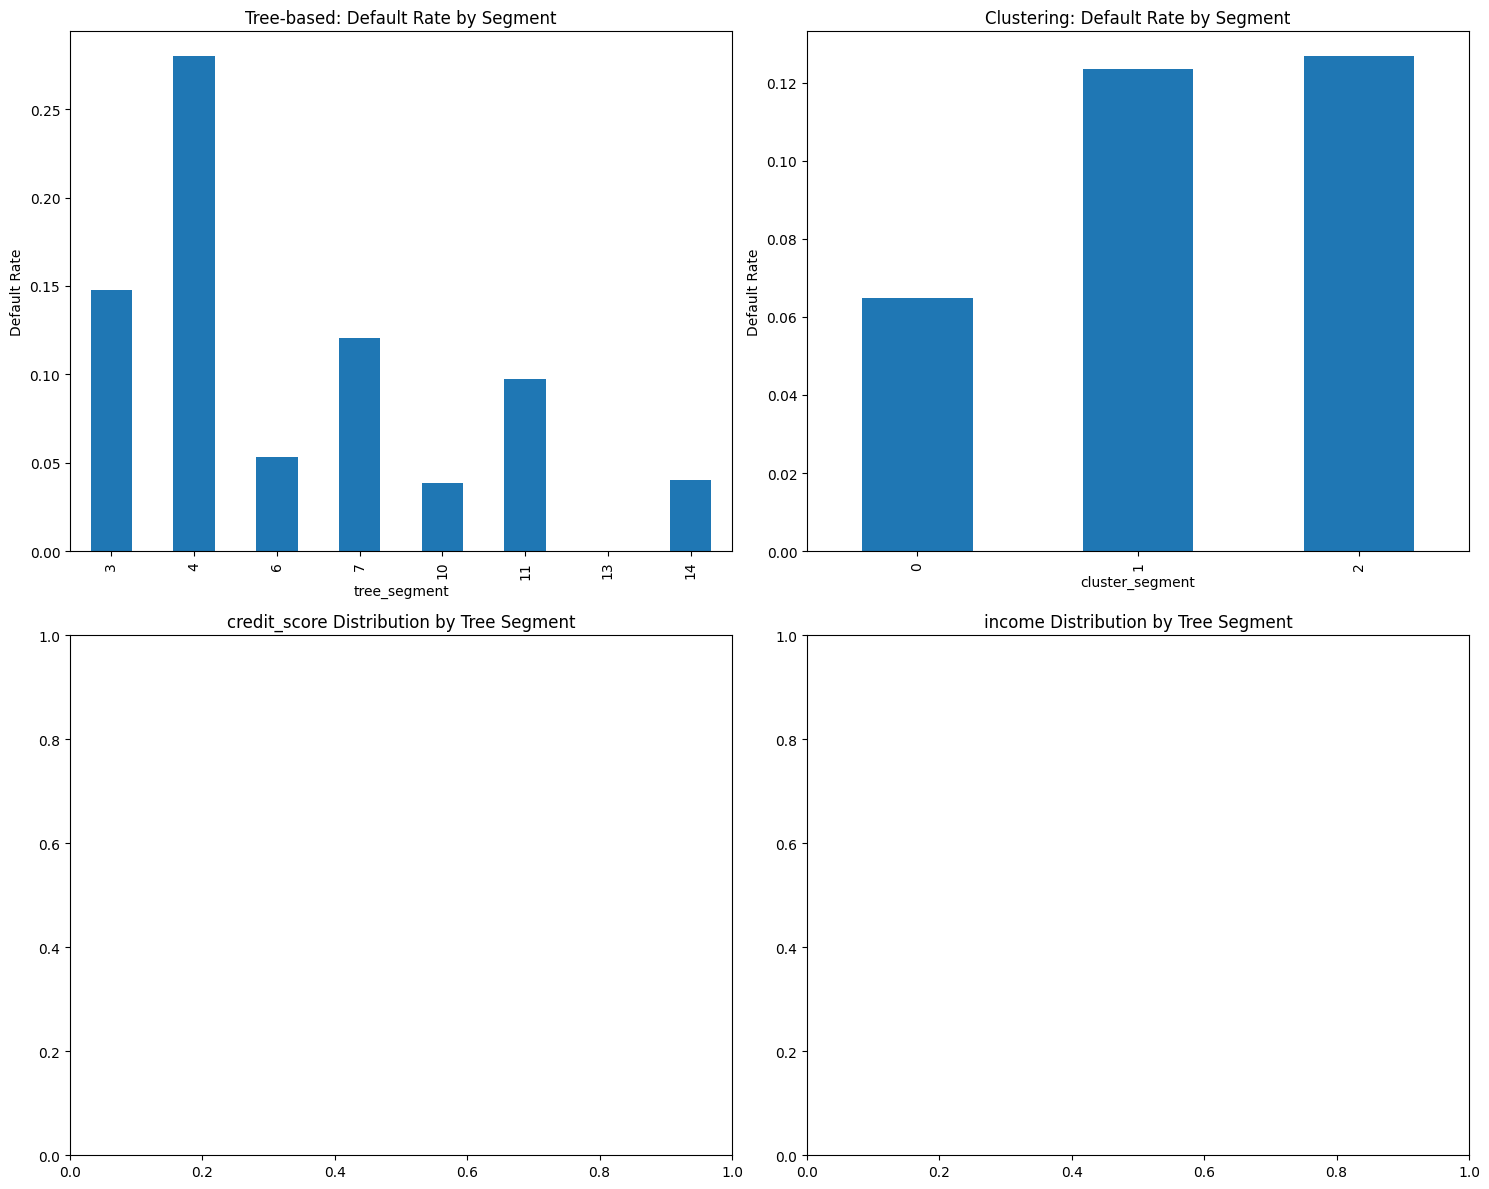

In [5]:
def evaluate_segmentation_approaches(df, results):
    """
    Evaluate and compare different segmentation approaches
    """
    # 1. Statistical Analysis
    def calculate_segment_metrics(df, segment_col):
        metrics = {
            # Population size (should be reasonably balanced)
            'population_ratio': df[segment_col].value_counts(normalize=True).min(),
            
            # Default rate separation (higher is better)
            'default_rate_range': (
                df.groupby(segment_col)['default'].mean().max() - 
                df.groupby(segment_col)['default'].mean().min()
            ),
            
            # Information Value (IV) of segmentation
            'iv': calculate_iv(df, segment_col, 'default'),
            
            # Number of segments
            'n_segments': df[segment_col].nunique()
        }
        return metrics

    def calculate_iv(df, segment_col, target_col):
        """Calculate Information Value of segmentation"""
        segments = pd.crosstab(df[segment_col], df[target_col])
        good_dist = segments[0] / segments[0].sum()
        bad_dist = segments[1] / segments[1].sum()
        
        # Add small value to avoid division by zero
        good_dist = good_dist.clip(lower=0.0001)
        bad_dist = bad_dist.clip(lower=0.0001)
        
        woe = np.log(good_dist / bad_dist)
        iv = ((good_dist - bad_dist) * woe).sum()
        return iv

    # Calculate metrics for both approaches
    tree_metrics = calculate_segment_metrics(df, 'tree_segment')
    cluster_metrics = calculate_segment_metrics(df, 'cluster_segment')
    
    # 2. Create comparison table
    comparison = pd.DataFrame({
        'Tree-based': tree_metrics,
        'Clustering': cluster_metrics
    })
    
    # 3. Visualize comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Population distribution
    for i, (name, segment_col) in enumerate([
        ('Tree-based', 'tree_segment'), 
        ('Clustering', 'cluster_segment')
    ]):
        df.groupby(segment_col)['default'].mean().plot(
            kind='bar',
            ax=axes[0,i],
            title=f'{name}: Default Rate by Segment'
        )
        axes[0,i].set_ylabel('Default Rate')
    
    # Feature distributions
    for i, feature in enumerate(['credit_score', 'income']):
        sns.boxplot(
            data=df.melt(
                id_vars=['tree_segment', 'cluster_segment', feature],
                value_vars=[feature]
            ),
            x='tree_segment',
            y='value',
            ax=axes[1,i]
        )
        axes[1,i].set_title(f'{feature} Distribution by Tree Segment')
    
    plt.tight_layout()
    
    # 4. Draw conclusions
    conclusions = []
    
    # Population balance
    if tree_metrics['population_ratio'] > cluster_metrics['population_ratio']:
        conclusions.append("Tree-based segmentation provides more balanced population splits")
    else:
        conclusions.append("Clustering provides more balanced population splits")
    
    # Default rate separation
    if tree_metrics['default_rate_range'] > cluster_metrics['default_rate_range']:
        conclusions.append("Tree-based segmentation shows better separation of default rates")
    else:
        conclusions.append("Clustering shows better separation of default rates")
    
    # Information Value
    if tree_metrics['iv'] > cluster_metrics['iv']:
        conclusions.append("Tree-based segmentation has higher predictive power (IV)")
    else:
        conclusions.append("Clustering has higher predictive power (IV)")
    
    # Business interpretability
    conclusions.append(
        "Tree-based segmentation provides clear, rule-based segments that are "
        "easier to interpret and implement"
    )
    
    return {
        'comparison': comparison,
        'visualization': fig,
        'conclusions': conclusions,
        'recommendation': recommend_approach(tree_metrics, cluster_metrics)
    }

def recommend_approach(tree_metrics, cluster_metrics):
    """
    Make a final recommendation based on metrics
    """
    points = {
        'tree': 0,
        'cluster': 0
    }
    
    # Score each approach
    if tree_metrics['population_ratio'] > cluster_metrics['population_ratio']:
        points['tree'] += 1
    else:
        points['cluster'] += 1
        
    if tree_metrics['default_rate_range'] > cluster_metrics['default_rate_range']:
        points['tree'] += 2  # Weight this more heavily
    else:
        points['cluster'] += 2
        
    if tree_metrics['iv'] > cluster_metrics['iv']:
        points['tree'] += 2  # Weight this more heavily
    else:
        points['cluster'] += 2
        
    # Add point for interpretability
    points['tree'] += 1
    
    if points['tree'] > points['cluster']:
        return (
            "Recommend using Tree-based segmentation due to better separation "
            "of risk and clearer business interpretation"
        )
    elif points['tree'] < points['cluster']:
        return (
            "Recommend using Clustering due to better statistical properties, "
            "but consider implementation complexity"
        )
    else:
        return (
            "Both approaches have merit. Consider using Tree-based segmentation "
            "for easier implementation and interpretation"
        )

# Run evaluation
evaluation = evaluate_segmentation_approaches(df, results)

# Print results
print("\nSegmentation Comparison:")
print(evaluation['comparison'])
print("\nConclusions:")
for i, conclusion in enumerate(evaluation['conclusions'], 1):
    print(f"{i}. {conclusion}")
print("\nFinal Recommendation:")
print(evaluation['recommendation'])

# Show comparison plots
plt.show()

/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous value


Feature Metrics:
                         iv  mutual_info    f_stat  stability  uniqueness
age                0.097432     0.304785  0.351315   0.269563       0.966
income             0.170277     0.354797  8.194086   0.524322       1.000
credit_score       0.136405     0.343707  4.907223   0.075616       1.000
loan_amount        0.220565     0.354797  0.555892   0.424022       1.000
employment_length  0.140446     0.254145  0.837321   0.426048       0.985

Feature Scores:
                   total_score   iv_score   mi_score  stability_score  \
loan_amount          83.534928  40.000000  30.000000         3.825907   
credit_score         80.673526  24.737316  29.062252        17.115651   
income               70.617130  30.880067  30.000000         0.000000   
age                  62.932804  17.669411  25.771152         9.717660   
employment_length    60.370264  25.470250  21.489339         3.748607   

                   correlation_penalty  
loan_amount                   9.709022  


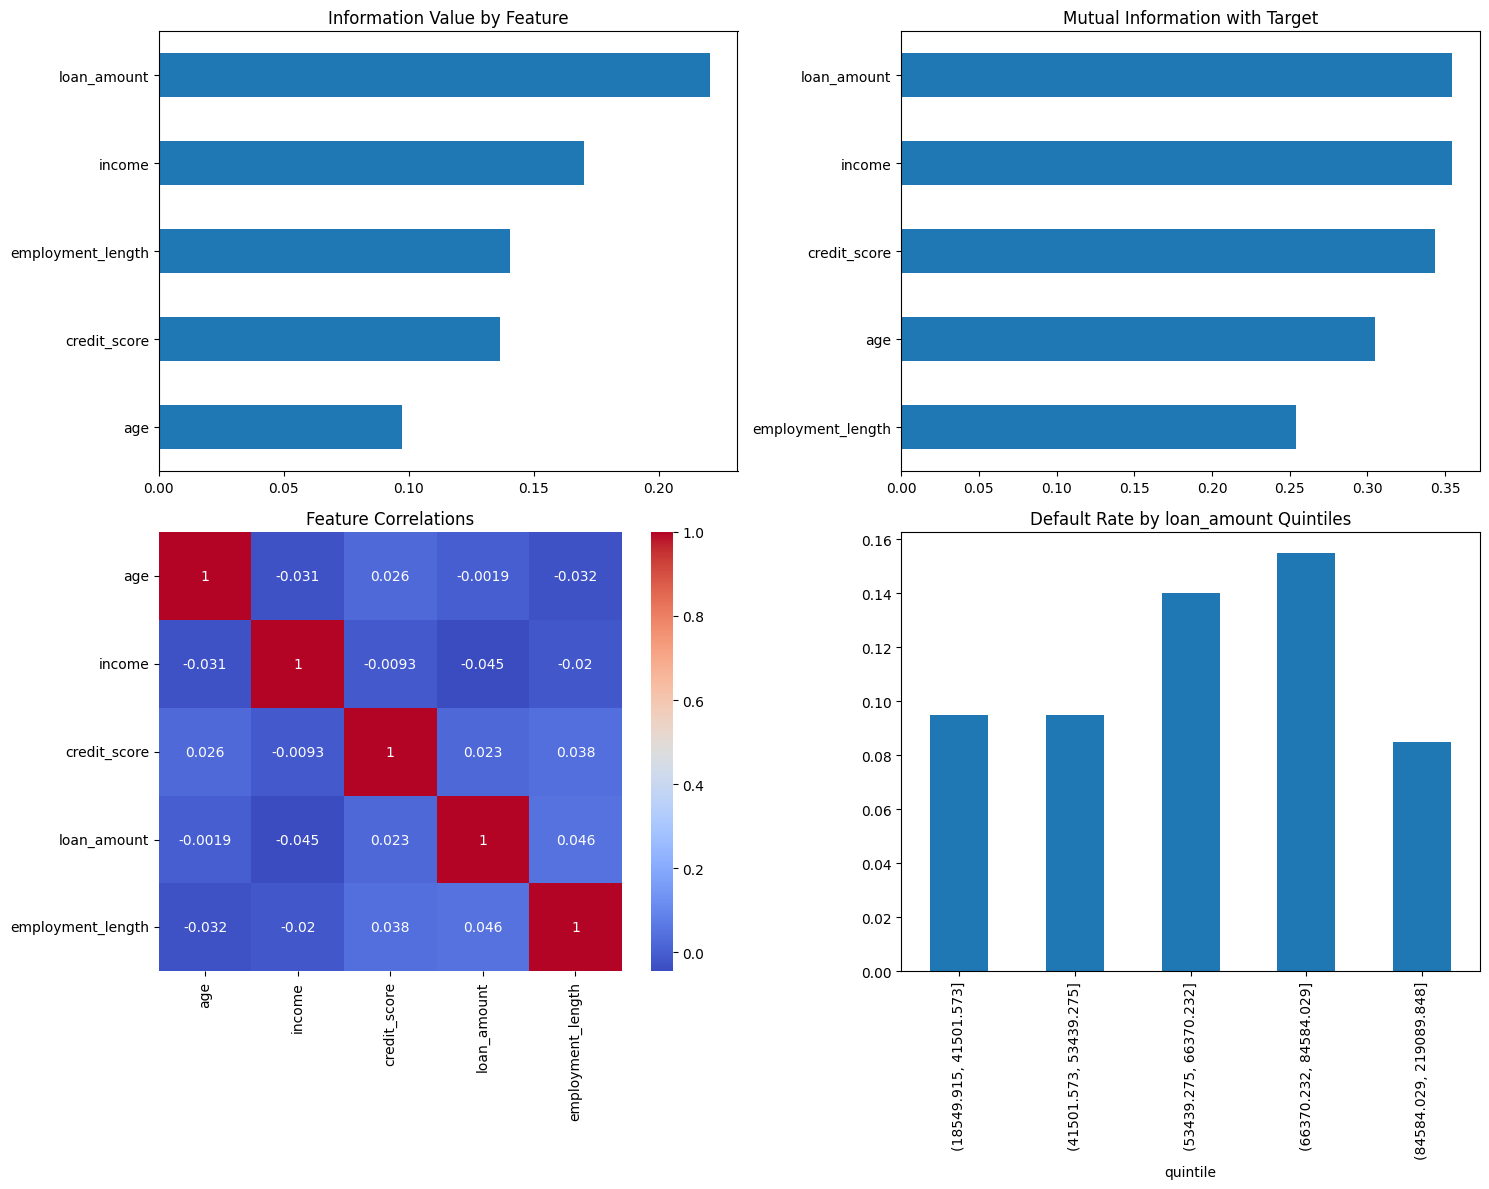

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mutual_info_score

def analyze_segmentation_features(df, target='default'):
    """
    Analyze features to determine their suitability for segmentation
    """
    features = [col for col in df.columns if col not in [target, 'tree_segment', 'cluster_segment']]
    
    # 1. Calculate metrics for each feature
    feature_metrics = {}
    for feature in features:
        metrics = {
            # Information Value
            'iv': calculate_information_value(df, feature, target),
            
            # Mutual Information with target
            'mutual_info': mutual_info_score(df[feature].round(2), df[target]),
            
            # ANOVA F-statistic (for continuous features)
            'f_stat': calculate_f_statistic(df, feature, target),
            
            # Business stability (using coefficient of variation)
            'stability': df[feature].std() / df[feature].mean(),
            
            # Number of unique values (normalized)
            'uniqueness': len(df[feature].unique()) / len(df)
        }
        feature_metrics[feature] = metrics
    
    metrics_df = pd.DataFrame(feature_metrics).T
    
    # 2. Visualize feature relationships
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot Information Value
    metrics_df['iv'].sort_values().plot(
        kind='barh', ax=axes[0,0], title='Information Value by Feature'
    )
    
    # Plot Mutual Information
    metrics_df['mutual_info'].sort_values().plot(
        kind='barh', ax=axes[0,1], title='Mutual Information with Target'
    )
    
    # Plot correlation heatmap
    sns.heatmap(
        df[features].corr(), 
        annot=True, 
        cmap='coolwarm',
        ax=axes[1,0]
    )
    axes[1,0].set_title('Feature Correlations')
    
    # Plot default rates across feature quintiles
    feature_with_highest_iv = metrics_df['iv'].idxmax()
    df['quintile'] = pd.qcut(df[feature_with_highest_iv], q=5)
    df.groupby('quintile')[target].mean().plot(
        kind='bar',
        ax=axes[1,1],
        title=f'Default Rate by {feature_with_highest_iv} Quintiles'
    )
    
    plt.tight_layout()
    
    # 3. Score features for segmentation
    feature_scores = score_features_for_segmentation(metrics_df, df[features].corr())
    
    return {
        'metrics': metrics_df,
        'visualization': fig,
        'scores': feature_scores,
        'recommendation': recommend_segmentation_features(feature_scores, metrics_df)
    }

def calculate_information_value(df, feature, target):
    """Calculate Information Value for a feature"""
    # Create bins for continuous features
    if df[feature].nunique() > 10:
        x = pd.qcut(df[feature], q=10, duplicates='drop')
    else:
        x = df[feature]
        
    # Calculate WOE and IV
    cross_tab = pd.crosstab(x, df[target])
    good_dist = cross_tab[0] / cross_tab[0].sum()
    bad_dist = cross_tab[1] / cross_tab[1].sum()
    
    # Add small value to avoid division by zero
    good_dist = good_dist.clip(lower=0.0001)
    bad_dist = bad_dist.clip(lower=0.0001)
    
    woe = np.log(good_dist / bad_dist)
    iv = ((good_dist - bad_dist) * woe).sum()
    
    return iv

def calculate_f_statistic(df, feature, target):
    """Calculate ANOVA F-statistic"""
    groups = [group[feature].values for name, group in df.groupby(target)]
    f_stat, _ = stats.f_oneway(*groups)
    return f_stat

def score_features_for_segmentation(metrics_df, correlation_matrix):
    """Score features based on their suitability for segmentation"""
    scores = {}
    
    for feature in metrics_df.index:
        score = 0
        
        # Information Value weight (0-40 points)
        iv_score = 40 * (metrics_df.loc[feature, 'iv'] / metrics_df['iv'].max())
        score += iv_score
        
        # Mutual Information weight (0-30 points)
        mi_score = 30 * (metrics_df.loc[feature, 'mutual_info'] / metrics_df['mutual_info'].max())
        score += mi_score
        
        # Stability weight (0-20 points)
        # Lower stability (coefficient of variation) is better
        stability_score = 20 * (1 - metrics_df.loc[feature, 'stability'] / metrics_df['stability'].max())
        score += stability_score
        
        # Correlation penalty (0-10 points)
        # Penalize features that are highly correlated with others
        correlations = correlation_matrix[feature].abs()
        correlation_penalty = 10 * (1 - (correlations.sum() - 1) / (len(correlations) - 1))
        score += correlation_penalty
        
        scores[feature] = {
            'total_score': score,
            'iv_score': iv_score,
            'mi_score': mi_score,
            'stability_score': stability_score,
            'correlation_penalty': correlation_penalty
        }
    
    return pd.DataFrame(scores).T.sort_values('total_score', ascending=False)

def recommend_segmentation_features(feature_scores, metrics_df):
    """Provide recommendations for segmentation features"""
    top_features = feature_scores.head(2).index.tolist()
    
    recommendations = [
        f"Primary recommended feature: {top_features[0]}",
        f"Secondary recommended feature: {top_features[1]}",
        "\nRationale:",
        f"1. {top_features[0]} shows the highest combined score considering:",
        f"   - Information Value: {metrics_df.loc[top_features[0], 'iv']:.3f}",
        f"   - Mutual Information: {metrics_df.loc[top_features[0], 'mutual_info']:.3f}",
        f"   - Stability: {metrics_df.loc[top_features[0], 'stability']:.3f}",
        "\nConsiderations for implementation:",
        "- Use these features as primary splitting criteria in decision trees",
        "- Consider business context and interpretability",
        "- Monitor stability of these features over time"
    ]
    
    return "\n".join(recommendations)

# Run the analysis
feature_analysis = analyze_segmentation_features(df)

# Print results
print("\nFeature Metrics:")
print(feature_analysis['metrics'])
print("\nFeature Scores:")
print(feature_analysis['scores'])
print("\nRecommendations:")
print(feature_analysis['recommendation'])

# Show visualizations
plt.show()